# Vendor Performance — ML Models

| # | Model | Type | Algorithm |
|---|-------|------|-----------|
| 1 | Predict Profit Margin | Regression | XGBoost |
| 2 | Classify Vendors (High / Medium / Low) | Classification | XGBoost |
| 3 | Detect Risky Vendors | Anomaly Detection | Rule + Isolation Forest |


## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')

# Warm color palette — used for every plot in this notebook
WARM = ['#F97316', '#FB923C', '#FBBF24', '#EF4444', '#F59E0B']
sns.set_theme(style='whitegrid')
sns.set_palette(WARM)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 1. Load & Clean Data

In [2]:
df_raw = pd.read_csv('dataset/vendor_sales_summary.csv', sep=';')
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (10648, 18)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594


In [3]:
# ── Cleaning ────────────────────────────────────────────────────────────────
# 1. Drop rows with zero sales — nothing to learn from a vendor that sold nothing.
df = df_raw[df_raw['TotalSalesDollars'] > 0].copy()

# 2. Drop extreme ProfitMargin outliers (< -200) — confirmed data artifacts in EDA.
df = df[df['ProfitMargin'] > -200].copy()

# 3. Cap StockTurnover at the 99th percentile — a few tiny-volume rows have
#    impossibly high turnover ratios.
cap = df['StockTurnover'].quantile(0.99)
df['StockTurnover'] = df['StockTurnover'].clip(upper=cap)

# 4. Two simple engineered features:
#    - OrderSize: which quantity quartile a purchase falls into (0=smallest .. 3=largest)
#    - PriceMarkup: how much the selling price is marked up over the purchase price
df['OrderSize']    = pd.qcut(df['TotalPurchaseQuantity'], q=4, labels=False)
df['PriceMarkup']  = (df['ActualPrice'] - df['PurchasePrice']) / df['PurchasePrice'].clip(lower=0.01)

print(f"Clean shape: {df.shape}")
df[['ProfitMargin', 'StockTurnover', 'GrossProfit']].describe().round(2)

Clean shape: (10019, 20)


,ProfitMargin,StockTurnover,GrossProfit
count,10019.00,10019.00,10019.00
mean,25.58,1.54,13099.08
std,41.54,2.43,47564.32
min,-198.54,0.20,-38161.69
25%,19.57,0.87,122.64
50%,31.44,0.99,1812.02
75%,40.97,1.06,9701.44
max,99.72,18.96,1290667.91


## 2. Feature Matrix

Nine columns. No target leakage: `ProfitMargin`, `StockTurnover` and `GrossProfit` are left out because they either *are* the target or are used to build it.

In [4]:
FEATURES = [
    'PurchasePrice', 'ActualPrice', 'Volume',
    'TotalPurchaseQuantity', 'TotalSalesQuantity',
    'TotalPurchaseDollars', 'TotalSalesDollars',
    'PriceMarkup', 'OrderSize',
]

X = df[FEATURES].astype(float)
print("Feature matrix shape:", X.shape)
X.head(3)

Feature matrix shape: (10019, 9)


,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalSalesQuantity,TotalPurchaseDollars,TotalSalesDollars,PriceMarkup,OrderSize
0,26.27,36.99,1750.0,145080.0,142049.0,3811251.60,5.101920e+06,0.408070,3.0
1,23.19,28.99,1750.0,164038.0,160247.0,3804041.22,4.819073e+06,0.250108,3.0
2,18.24,24.99,1750.0,187407.0,187140.0,3418303.68,4.538121e+06,0.370066,3.0


---
## Model 1 — Predict Profit Margin (Regression)

> **Goal:** given a vendor-brand's features, predict its `ProfitMargin` (%).
>
> **Algorithm:** a single XGBoost regressor

In [5]:
y_reg = df['ProfitMargin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (8015, 9) | Test: (2004, 9)


In [6]:
xgb_reg = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=RANDOM_STATE, verbosity=0
)
xgb_reg.fit(X_train, y_train)
preds = xgb_reg.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")

MAE  = 6.17
RMSE = 9.40
R²   = 0.9440


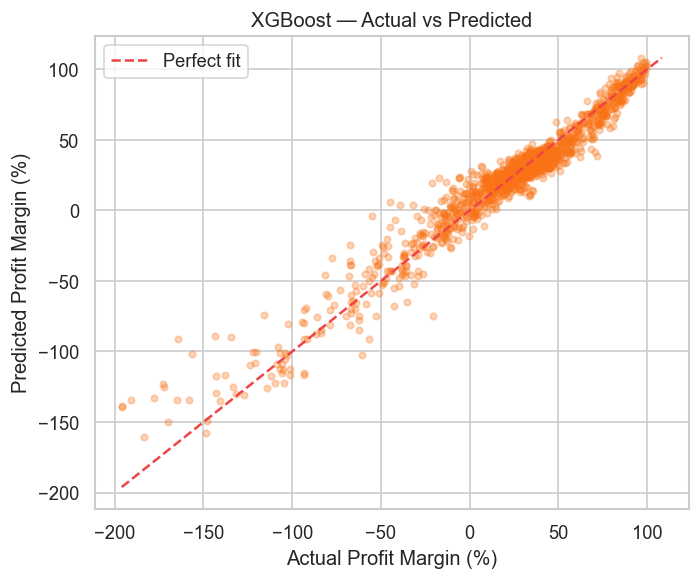

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, preds, alpha=0.3, s=15, color=WARM[0])
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, '--', lw=1.5, color=WARM[3], label='Perfect fit')
plt.xlabel('Actual Profit Margin (%)')
plt.ylabel('Predicted Profit Margin (%)')
plt.title('XGBoost — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

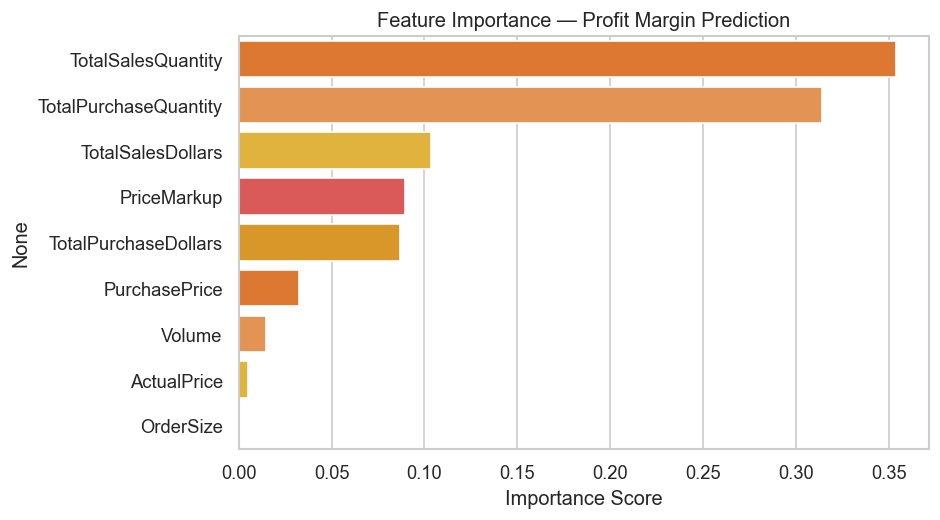

In [8]:
feat_imp = pd.Series(xgb_reg.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=WARM)
plt.title('Feature Importance — Profit Margin Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Model 2 — Vendor Performance Classification (High / Medium / Low)

> **Goal:** label each vendor-brand **High**, **Medium**, or **Low** performing, then train a classifier so new vendors get labelled automatically.

### Label construction (simple version)

Rank each vendor by `ProfitMargin` and by `StockTurnover` as **percentiles (0–1)**, add the two together, and split the result into three equal-sized groups. No scalers to fit or save — it's just `rank(pct=True)`.

In [9]:
df['CompositeScore'] = (
    df['ProfitMargin'].rank(pct=True) + df['StockTurnover'].rank(pct=True)
)
df['PerformanceCategory'] = pd.qcut(
    df['CompositeScore'], q=3, labels=['Low', 'Medium', 'High']
)

print(df['PerformanceCategory'].value_counts())
print()
print(df.groupby('PerformanceCategory', observed=True)[['ProfitMargin', 'StockTurnover']].median().round(2))

PerformanceCategory
Low       3340
Medium    3340
High      3339
Name: count, dtype: int64

                     ProfitMargin  StockTurnover
PerformanceCategory                             
Low                          5.84           0.75
Medium                      31.48           0.99
High                        51.64           1.35


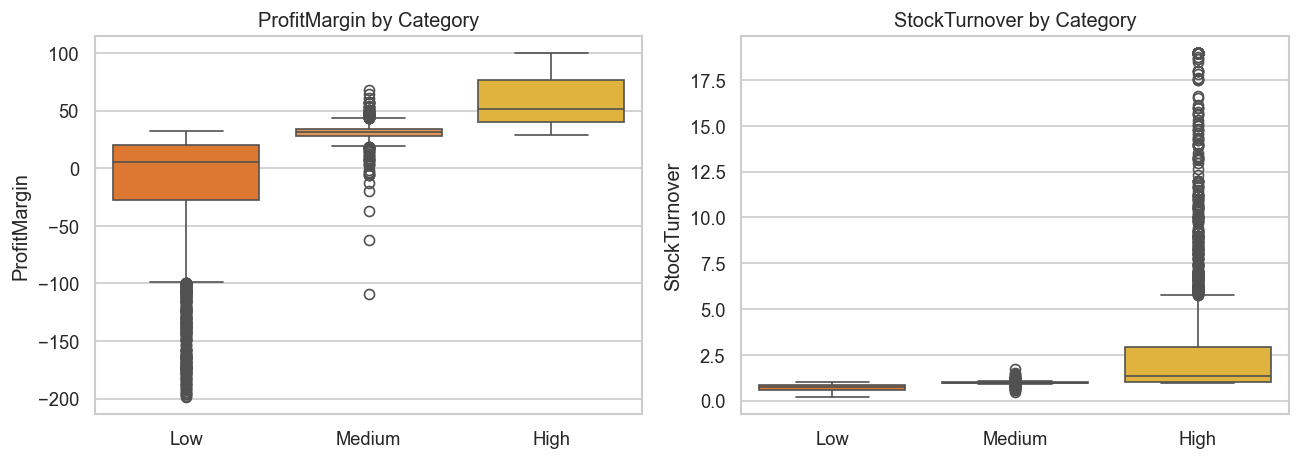

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ['ProfitMargin', 'StockTurnover']):
    sns.boxplot(
        data=df, x='PerformanceCategory', y=col,
        order=['Low', 'Medium', 'High'], palette=WARM, ax=ax
    )
    ax.set_title(f'{col} by Category')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [11]:
le = LabelEncoder()
y_clf = le.fit_transform(df['PerformanceCategory'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)
print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print("Classes:", list(le.classes_))

Train: (8015, 9) | Test: (2004, 9)
Classes: ['High', 'Low', 'Medium']


In [12]:
xgb_clf = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0
)
xgb_clf.fit(X_train_c, y_train_c)
clf_preds = xgb_clf.predict(X_test_c)

print(classification_report(y_test_c, clf_preds, target_names=le.classes_))

              precision    recall  f1-score   support

        High       0.88      0.76      0.81       668
         Low       0.82      0.83      0.83       668
      Medium       0.66      0.74      0.70       668

    accuracy                           0.78      2004
   macro avg       0.79      0.78      0.78      2004
weighted avg       0.79      0.78      0.78      2004



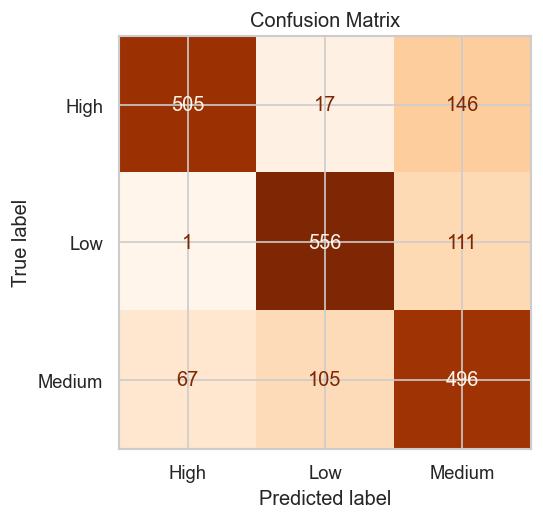

In [13]:
cm = confusion_matrix(y_test_c, clf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

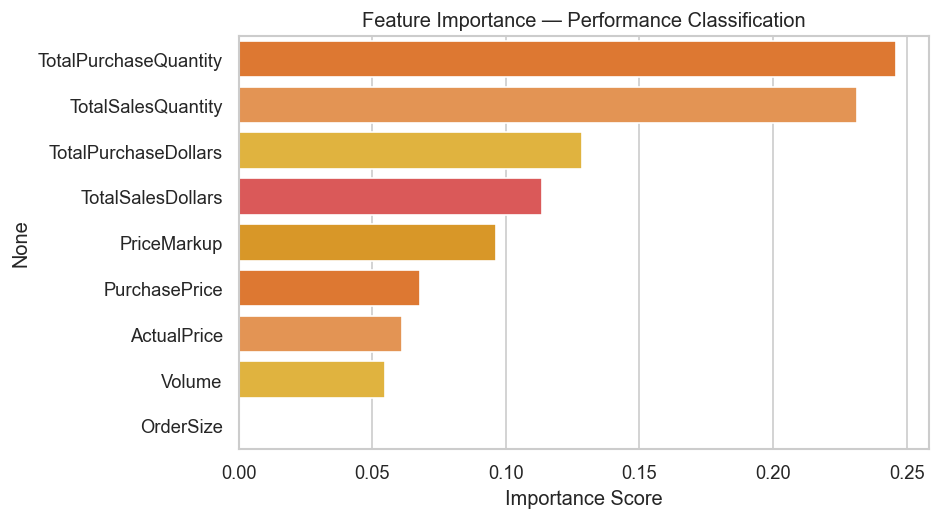

In [14]:
feat_imp_clf = pd.Series(xgb_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=feat_imp_clf.values, y=feat_imp_clf.index, palette=WARM)
plt.title('Feature Importance — Performance Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Model 3 — Risky Vendor Detection (Anomaly Detection)

> **Goal:** flag vendors that look financially unhealthy — **low profit margin AND low stock turnover**.
>
> Two simple pieces:
> - **Rule-based flag** — bottom 25% margin *and* bottom 25% turnover.
> - **Isolation Forest** — an unsupervised model trained on 4 core financial columns to catch subtler anomalies the rule misses.

In [15]:
pm_thresh = df['ProfitMargin'].quantile(0.25)
st_thresh = df['StockTurnover'].quantile(0.25)

df['RiskFlag_Rule'] = (
    (df['ProfitMargin'] < pm_thresh) & (df['StockTurnover'] < st_thresh)
).astype(int)

print(f"ProfitMargin  25th pct: {pm_thresh:.2f}%")
print(f"StockTurnover 25th pct: {st_thresh:.4f}")
print(f"Flagged risky (rule-based): {df['RiskFlag_Rule'].sum()} "
      f"({df['RiskFlag_Rule'].mean()*100:.1f}% of vendors)")

ProfitMargin  25th pct: 19.57%
StockTurnover 25th pct: 0.8651
Flagged risky (rule-based): 2174 (21.7% of vendors)


In [16]:
ANOMALY_FEATURES = ['ProfitMargin', 'StockTurnover', 'GrossProfit', 'SalestoPurchaseRatio']

scaler = StandardScaler()
X_anomaly = scaler.fit_transform(df[ANOMALY_FEATURES])

iso = IsolationForest(n_estimators=100, contamination=0.1, random_state=RANDOM_STATE)
iso.fit(X_anomaly)

df['RiskFlag_IsoForest'] = (iso.predict(X_anomaly) == -1).astype(int)
df['AnomalyScore']       = -iso.decision_function(X_anomaly)

print(f"Flagged risky (Isolation Forest): {df['RiskFlag_IsoForest'].sum()} "
      f"({df['RiskFlag_IsoForest'].mean()*100:.1f}% of vendors)")

Flagged risky (Isolation Forest): 1002 (10.0% of vendors)


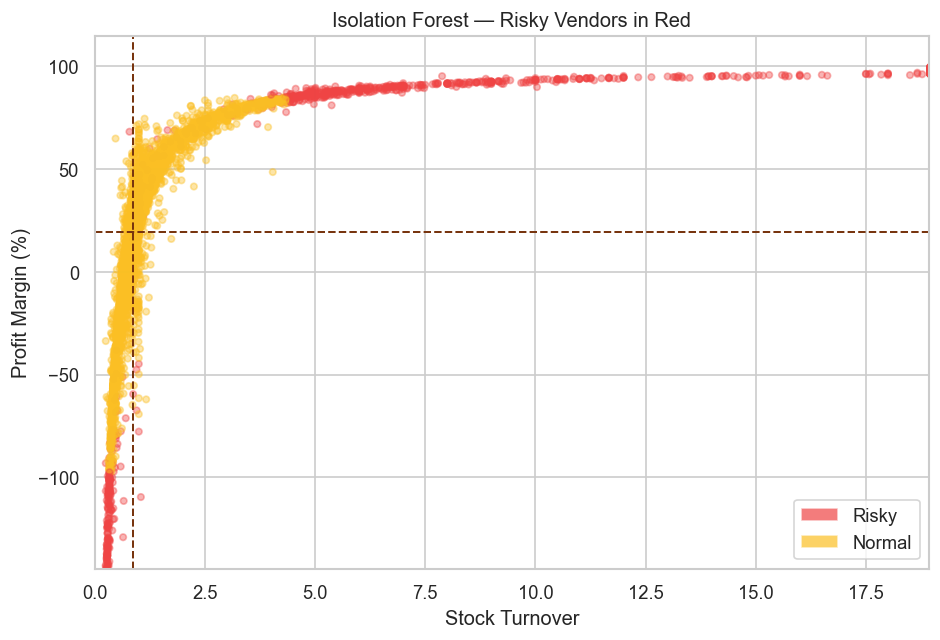

In [17]:
from matplotlib.patches import Patch

plt.figure(figsize=(8, 5.5))
colors = df['RiskFlag_IsoForest'].map({0: '#FBBF24', 1: '#EF4444'})
plt.scatter(df['StockTurnover'], df['ProfitMargin'], c=colors, alpha=0.4, s=15)
plt.axvline(st_thresh, color='#78350F', linestyle='--', lw=1.2)
plt.axhline(pm_thresh, color='#78350F', linestyle='--', lw=1.2)
plt.xlim(left=0, right=df['StockTurnover'].quantile(0.99))
plt.ylim(bottom=df['ProfitMargin'].quantile(0.01))
plt.xlabel('Stock Turnover')
plt.ylabel('Profit Margin (%)')
plt.title('Isolation Forest — Risky Vendors in Red')
plt.legend(handles=[
    Patch(facecolor='#EF4444', alpha=0.7, label='Risky'),
    Patch(facecolor='#FBBF24', alpha=0.7, label='Normal'),
])
plt.tight_layout()
plt.show()

---
## Summary

| Model | Algorithm | Key Metric |
|-------|-----------|------------|
| Regression (Profit Margin) | XGBoost | MAE, RMSE, R² |
| Classification (High/Med/Low) | XGBoost | Accuracy, F1 per class |
| Anomaly Detection (Risky) | Rule + Isolation Forest | Anomaly Score |

**Design choices:**
- One algorithm per task — no model-vs-model comparisons to explain.
- One shared 9-feature set for both supervised models — easy to name from memory.
- Labels built with `rank(pct=True)` — no scaler object to fit, save, or explain.
- `GrossProfit`, `ProfitMargin`, `StockTurnover` excluded from supervised features to avoid target leakage.
- Risk detection = a transparent rule (business-readable) + Isolation Forest (catches subtler cases).

In [18]:
"""
Run this last cell once to export every artifact the Streamlit app needs.
Commit the /models/ folder with the app.
"""
import joblib, os

os.makedirs("models", exist_ok=True)

# Shared feature list (used by both regression & classification)
joblib.dump(FEATURES, "models/features.pkl")

# Regression
joblib.dump(xgb_reg, "models/xgb_reg.pkl")
joblib.dump((X_test, y_test), "models/reg_test_split.pkl")

# Classification
joblib.dump(xgb_clf, "models/xgb_clf.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump((X_test_c, y_test_c), "models/clf_test_split.pkl")

# Anomaly detection
joblib.dump(iso, "models/iso_forest.pkl")
joblib.dump(scaler, "models/iso_scaler.pkl")
joblib.dump(ANOMALY_FEATURES, "models/anomaly_features.pkl")
joblib.dump({"pm": float(pm_thresh), "st": float(st_thresh)}, "models/iso_thresholds.pkl")

saved = sorted(os.listdir("models"))
print(f"Saved {len(saved)} files to /models/:")
for f in saved:
    print(" ", f)

Saved 10 files to /models/:
  anomaly_features.pkl
  clf_test_split.pkl
  features.pkl
  iso_forest.pkl
  iso_scaler.pkl
  iso_thresholds.pkl
  label_encoder.pkl
  reg_test_split.pkl
  xgb_clf.pkl
  xgb_reg.pkl
